# Milestone 1 Pre-processing

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import re
from datetime import datetime
import matplotlib.cm as cm
import seaborn as sns

In [29]:
def nan_percentage_plot(df):
    df_missing_val = df.isnull().sum()[df.isnull().sum() > 0].reset_index(name='missing')
    df_missing_val['percentage_missing'] = df_missing_val['missing'] / df.shape[0] *100

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.bar(
        df_missing_val['index'],
        df_missing_val['percentage_missing'],
        edgecolor='white',
        linewidth=0.8,
        width=0.6
    )

    ax.set_xlabel('Column name', fontsize=12)
    ax.set_ylabel('% of NaNs', fontsize=12)
    ax.set_title('% of NaNs by Column', fontsize=14, fontweight='bold')

    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)
    ax.set_axisbelow(True)

    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

## 1) Pre-processing

### 1.2) ATP Matches Single

In [30]:
# ATP Tour Matches
files = [f for f in glob.glob('datasets/tennis_atp/atp_matches_*.csv')
         if re.search(r'atp_matches_\d{4}\.csv$', f)]

df_atp_matches = pd.concat(
    [pd.read_csv(f, parse_dates=['tourney_date'], date_format="%Y%m%d") for f in files],
    ignore_index=True)

df_atp_matches['tourney_date'] = pd.to_datetime(df_atp_matches['tourney_date'], errors='coerce')
df_atp_matches.sort_values(by=["tourney_date"])

df_atp_matches.to_csv("datasets/clean_datasets/all_atp_matches.csv")


In [31]:
df_atp_matches.head()

,tourney_id,tourney_name,surface,draw_size,tourney_level,tourney_date,match_num,winner_id,winner_seed,winner_entry,...,l_1stIn,l_1stWon,l_2ndWon,l_SvGms,l_bpSaved,l_bpFaced,winner_rank,winner_rank_points,loser_rank,loser_rank_points
0,2019-M020,Brisbane,Hard,32.0,A,2018-12-31,300,105453,2.0,NaN,...,54.0,34.0,20.0,14.0,10.0,15.0,9.0,3590.0,16.0,1977.0
1,2019-M020,Brisbane,Hard,32.0,A,2018-12-31,299,106421,4.0,NaN,...,52.0,36.0,7.0,10.0,10.0,13.0,16.0,1977.0,239.0,200.0
2,2019-M020,Brisbane,Hard,32.0,A,2018-12-31,298,105453,2.0,NaN,...,27.0,15.0,6.0,8.0,1.0,5.0,9.0,3590.0,40.0,1050.0
3,2019-M020,Brisbane,Hard,32.0,A,2018-12-31,297,104542,NaN,PR,...,60.0,38.0,9.0,11.0,4.0,6.0,239.0,200.0,31.0,1298.0
4,2019-M020,Brisbane,Hard,32.0,A,2018-12-31,296,106421,4.0,NaN,...,56.0,46.0,19.0,15.0,2.0,4.0,16.0,1977.0,18.0,1855.0


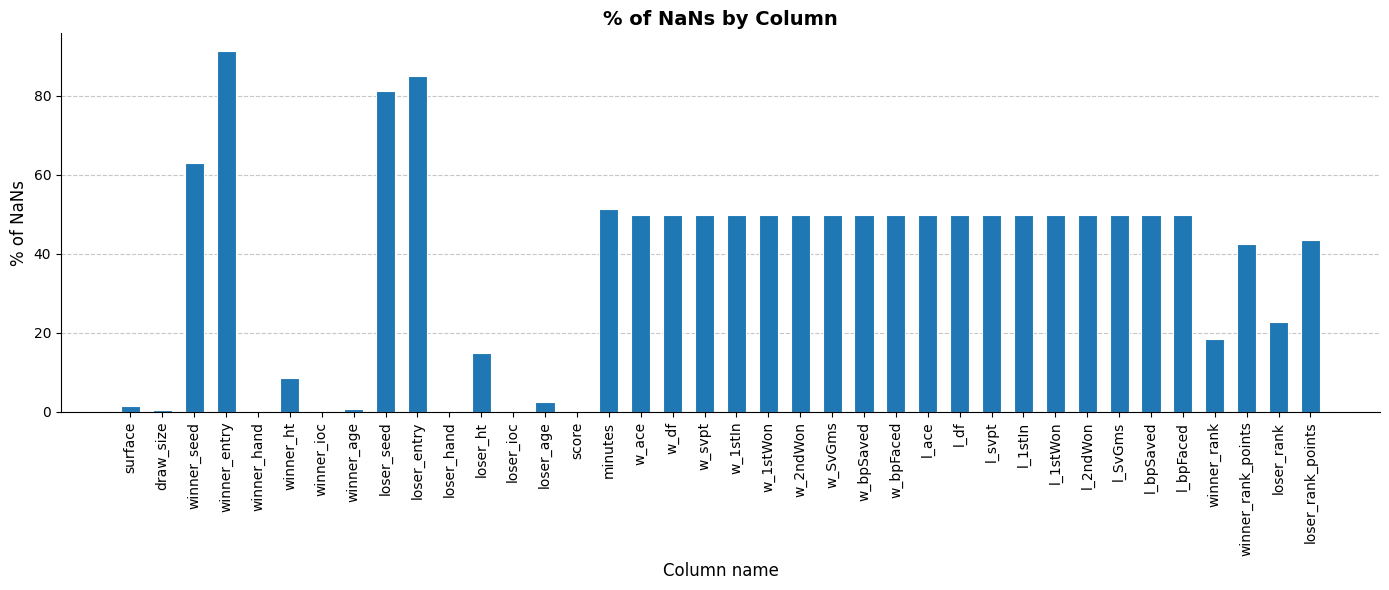

In [32]:
nan_percentage_plot(df_atp_matches)

### 1.2) Players

In [33]:
df_players = pd.read_csv('datasets/tennis_atp/atp_players.csv')

df_players['full_name'] = df_players['name_first']+ " " + df_players['name_last']
df_players['dob'] = pd.to_datetime(
    df_players['dob'].astype('Int64').astype(str),
    format='%Y%m%d',
    errors='coerce'
)
df_players.to_csv("datasets/clean_datasets/players_metadata.csv")
df_players.head()

/var/folders/s5/t7gxskm17flg_z98mm9kxymc0000gn/T/ipykernel_86578/2883038166.py:1: DtypeWarning: Columns (0: wikidata_id) have mixed types. Specify dtype option on import or set low_memory=False.
  df_players = pd.read_csv('datasets/tennis_atp/atp_players.csv')


,player_id,name_first,name_last,hand,dob,ioc,height,wikidata_id,full_name
0,100001,Gardnar,Mulloy,R,1913-11-22,USA,185.0,Q54544,Gardnar Mulloy
1,100002,Pancho,Segura,R,1921-06-20,ECU,168.0,Q54581,Pancho Segura
2,100003,Frank,Sedgman,R,1927-10-02,AUS,180.0,Q962049,Frank Sedgman
3,100004,Giuseppe,Merlo,R,1927-10-11,ITA,NaN,Q1258752,Giuseppe Merlo
4,100005,Richard,Gonzalez,R,1928-05-09,USA,188.0,Q53554,Richard Gonzalez


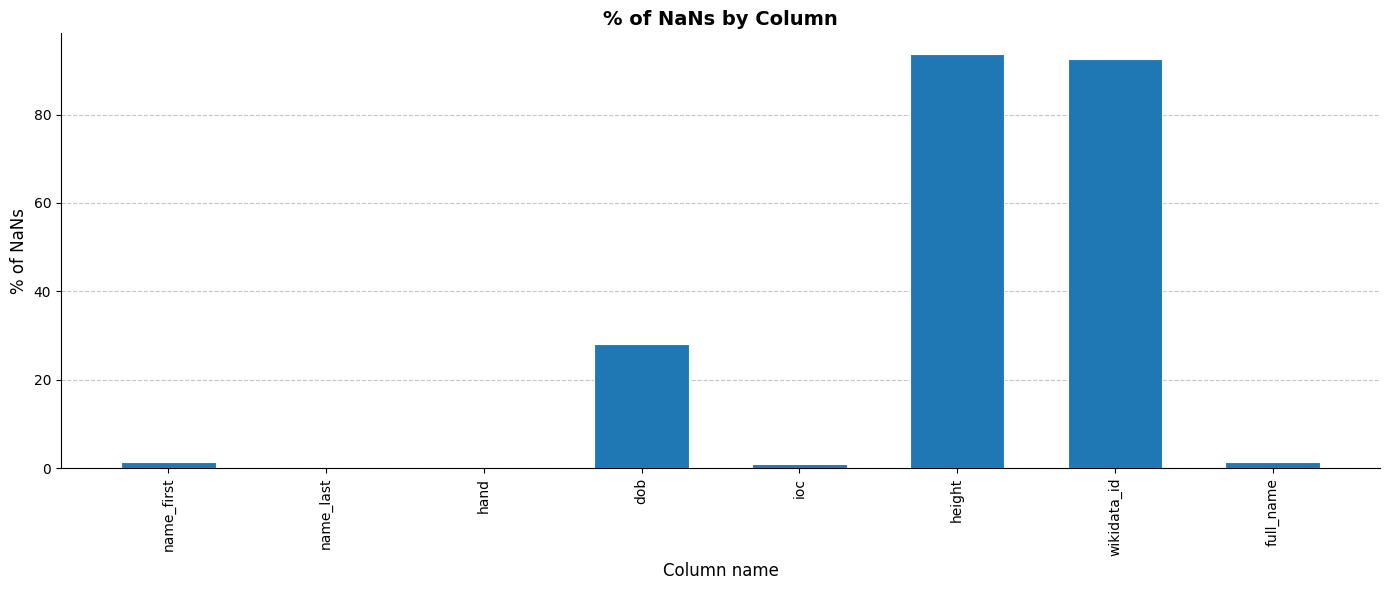

In [34]:
nan_percentage_plot(df_players)

### 1.3) Rankings

In [35]:
files = glob.glob('datasets/tennis_atp/atp_rankings_*.csv')

df_rankings = pd.concat(
    [pd.read_csv(f, parse_dates=['ranking_date'], date_format="%Y%m%d") for f in files],
    ignore_index=True)

df_rankings['ranking_date'] = pd.to_datetime(df_rankings['ranking_date'], errors='coerce')

df_rankings = df_rankings.merge(df_players[['full_name', 'player_id']],
                                left_on='player', right_on='player_id', how='left')
df_rankings.drop(columns=['player_id'], inplace=True)
df_rankings.to_csv("datasets/clean_datasets/all_rankings.csv")
df_rankings.head()

,ranking_date,rank,player,points,full_name
0,2000-01-10,1,101736,4135.0,Andre Agassi
1,2000-01-10,2,102338,2915.0,Yevgeny Kafelnikov
2,2000-01-10,3,101948,2419.0,Pete Sampras
3,2000-01-10,4,103017,2184.0,Nicolas Kiefer
4,2000-01-10,5,102856,2169.0,Gustavo Kuerten


### 1.4) Charting Stats

In [36]:
# Services
basic_service = pd.read_csv("datasets/charting_stats/charting-m-stats-ServeBasics.csv")

basic_service = basic_service[basic_service['row'] == 'Total']
basic_service = basic_service[['match_id', 'player','pts','pts_won','aces','unret','pts_won_lte_3_shots']]

service_direction = pd.read_csv("datasets/charting_stats/charting-m-stats-ServeDirection.csv")

service_direction = service_direction[service_direction['row'] == 'Total']
service_direction = service_direction[['match_id', 'player','deuce_wide','deuce_middle','deuce_t','ad_wide','ad_middle','ad_t', 'err_net','err_wide','err_deep','err_wide_deep']]

df_service = basic_service.merge(service_direction, on=['match_id','player'])

df_service.to_csv("datasets/clean_datasets/service_stats.csv")

df_service.head()

,match_id,player,pts,pts_won,aces,unret,pts_won_lte_3_shots,deuce_wide,deuce_middle,deuce_t,ad_wide,ad_middle,ad_t,err_net,err_wide,err_deep,err_wide_deep
0,20251221-M-NextGen_Finals-F-Alexander_Blockx-L...,Alexander Blockx,48,31,7,1,22,15,2,10,10,4,7,4,2,5,0
1,20251221-M-NextGen_Finals-F-Alexander_Blockx-L...,Learner Tien,52,41,1,1,18,10,4,13,16,0,9,7,3,7,2
2,20251219-M-NextGen_Finals-RR-Nishesh_Basavared...,Nishesh Basavareddy,55,44,8,0,33,20,4,7,14,4,6,8,9,8,2
3,20251219-M-NextGen_Finals-RR-Nishesh_Basavared...,Justin Engel,61,38,9,0,27,10,12,10,22,2,5,7,4,7,0
4,20251217-M-NextGen_Finals-RR-Rafael_Jodar-Lear...,Rafael Jodar,95,51,3,1,22,16,9,26,15,9,20,8,2,21,2


In [37]:
# Returns

return_depth = pd.read_csv("datasets/charting_stats/charting-m-stats-ReturnDepth.csv")
return_depth = return_depth[return_depth['row'] == 'Total']
return_depth = return_depth.drop(columns=['row'])

return_outcome = pd.read_csv("datasets/charting_stats/charting-m-stats-ReturnOutcomes.csv")
return_outcome = return_outcome[return_outcome['row'] == 'Total']
return_outcome = return_outcome.drop(columns=['row'])

df_return = return_depth.merge(return_outcome, on=['match_id','player'])
df_return.to_csv("datasets/clean_datasets/return_stats.csv")

df_return.head()

,match_id,player,returnable_x,shallow,deep,very_deep,unforced,err_net,err_deep,err_wide,err_wide_deep,pts,pts_won,returnable_y,returnable_won,in_play,in_play_won,winners,total_shots
0,20251221-M-NextGen_Finals-F-Alexander_Blockx-L...,Alexander Blockx,38,11,26,7,1,1,0,0,0,52,11,38,10,37,10,1,206
1,20251221-M-NextGen_Finals-F-Alexander_Blockx-L...,Learner Tien,34,8,22,8,2,2,0,0,0,48,17,34,16,32,16,0,192
2,20251219-M-NextGen_Finals-RR-Nishesh_Basavared...,Nishesh Basavareddy,39,13,26,7,0,0,0,0,0,61,23,39,22,39,22,2,205
3,20251219-M-NextGen_Finals-RR-Nishesh_Basavared...,Justin Engel,25,3,22,7,0,0,0,0,0,55,11,25,8,25,8,0,163
4,20251217-M-NextGen_Finals-RR-Rafael_Jodar-Lear...,Rafael Jodar,57,12,45,18,4,1,2,1,0,80,30,57,25,53,25,1,327


In [38]:
# Shots

shot_types = pd.read_csv("datasets/charting_stats/charting-m-stats-ShotTypes.csv")

shot_types_special = shot_types[shot_types['row'].isin(['Gs','Sl','Dr','Lo','Vo','Ov','Sw'])]
shot_types_special =shot_types_special[['match_id','player','row','shots']]
shot_types_special =shot_types_special.drop_duplicates(subset=['match_id', 'player', 'row'])
shot_types_special =shot_types_special.pivot(index=['match_id', 'player'], columns='row',values='shots')
shot_types_special.columns.name = None
shot_types_special = shot_types_special.reset_index().fillna(0)

shot_types_special.columns = (
    ['match_id', 'player'] +[f'{col}_shots' for col in shot_types_special.columns[2:]]
)
shot_types =shot_types[shot_types['row'] == 'Total']
shot_types = shot_types[['match_id', 'player','shots','pt_ending','winners','induced_forced','unforced']]

shot_direction = pd.read_csv("datasets/charting_stats/charting-m-stats-ShotDirection.csv")
shot_direction= shot_direction[shot_direction['row'] == 'Total'] 
shot_direction= shot_direction[['match_id', 'player','crosscourt','down_middle','down_the_line']]

df_shots = shot_types.merge(shot_types_special, on=['match_id','player']) 
df_shots = df_shots.merge(shot_direction, on=['match_id','player'])
df_shots.to_csv("datasets/clean_datasets/shots_stats.csv")

df_shots.head()


,match_id,player,shots,pt_ending,winners,induced_forced,unforced,Dr_shots,Gs_shots,Lo_shots,Ov_shots,Sl_shots,Sw_shots,Vo_shots,crosscourt,down_middle,down_the_line
0,20251221-M-NextGen_Finals-F-Alexander_Blockx-L...,Alexander Blockx,168,40,11,7,22,1.0,141.0,1.0,2.0,18.0,1.0,3.0,47,29,15
1,20251221-M-NextGen_Finals-F-Alexander_Blockx-L...,Learner Tien,162,32,8,14,10,0.0,140.0,1.0,1.0,16.0,0.0,4.0,57,18,15
2,20251219-M-NextGen_Finals-RR-Nishesh_Basavared...,Nishesh Basavareddy,138,27,11,11,5,4.0,108.0,0.0,0.0,24.0,0.0,2.0,46,26,10
3,20251219-M-NextGen_Finals-RR-Nishesh_Basavared...,Justin Engel,136,37,13,7,17,6.0,117.0,0.0,2.0,9.0,0.0,2.0,50,20,6
4,20251217-M-NextGen_Finals-RR-Rafael_Jodar-Lear...,Rafael Jodar,323,73,20,11,42,2.0,297.0,1.0,3.0,17.0,0.0,2.0,121,67,27


In [39]:
# Overview

stats_overview = pd.read_csv("datasets/charting_stats/charting-m-stats-Overview.csv")
stats_overview = stats_overview[stats_overview['set'] == 'Total'] 
stats_overview= stats_overview.drop(columns=['set','aces','serve_pts'])

stats_overview.to_csv("datasets/clean_datasets/overview_stats.csv")

stats_overview.head()


,match_id,player,dfs,first_in,first_won,second_in,second_won,bk_pts,bp_saved,return_pts,return_pts_won,winners,winners_fh,winners_bh,unforced,unforced_fh,unforced_bh
0,20251221-M-NextGen_Finals-F-Alexander_Blockx-L...,Alexander Blockx,1,38,28,10,3,1,0,52,11,19,8,3,23,14,8
1,20251221-M-NextGen_Finals-F-Alexander_Blockx-L...,Learner Tien,1,34,29,18,12,1,1,48,17,10,7,1,11,5,5
8,20251219-M-NextGen_Finals-RR-Nishesh_Basavared...,Nishesh Basavareddy,3,31,28,24,16,0,0,61,23,19,7,4,8,2,3
9,20251219-M-NextGen_Finals-RR-Nishesh_Basavared...,Justin Engel,1,44,32,17,6,4,3,55,11,22,10,3,18,11,6
16,20251217-M-NextGen_Finals-RR-Rafael_Jodar-Lear...,Rafael Jodar,2,64,41,31,10,14,7,80,30,24,16,4,44,27,15


In [40]:
# Net Points
net_points = pd.read_csv("datasets/charting_stats/charting-m-stats-NetPoints.csv")
net_points = net_points[net_points['row']== 'NetPoints'] 
net_points.to_csv("datasets/clean_datasets/netpoints_stats.csv")

net_points.head()

,match_id,player,row,net_pts,pts_won,net_winner,induced_forced,net_unforced,passed_at_net,passing_shot_induced_forced,total_shots
0,20251221-M-NextGen_Finals-F-Alexander_Blockx-L...,Alexander Blockx,NetPoints,6,5,4,1,0,0,0,32
4,20251221-M-NextGen_Finals-F-Alexander_Blockx-L...,Learner Tien,NetPoints,8,6,5,1,0,1,1,44
8,20251219-M-NextGen_Finals-RR-Nishesh_Basavared...,Nishesh Basavareddy,NetPoints,9,7,4,3,0,2,0,46
12,20251219-M-NextGen_Finals-RR-Nishesh_Basavared...,Justin Engel,NetPoints,11,7,5,2,2,0,2,57
16,20251217-M-NextGen_Finals-RR-Rafael_Jodar-Lear...,Rafael Jodar,NetPoints,16,12,6,5,1,3,0,102


## 2) Basic Statistics

### 2.1) ATP Matches

In [41]:
unique_winners = set(df_atp_matches['winner_id'].unique())
unique_loser = set(df_atp_matches['loser_id'].unique()) 
unique_players = unique_winners.union(unique_loser) 
upsets = df_atp_matches[df_atp_matches['loser_rank'] < df_atp_matches['winner_rank']]
youngest_winner = df_atp_matches.loc[df_atp_matches['winner_age'].idxmin(), ['winner_name','winner_age']].values
oldest_winner = df_atp_matches.loc[df_atp_matches['winner_age'].idxmax(), ['winner_name','winner_age']].values 
right_handed = len(df_atp_matches[df_atp_matches["winner_hand"] == "R"]) / len(df_atp_matches)
left_handed = len(df_atp_matches[df_atp_matches["winner_hand"] == "L"]) / len(df_atp_matches)

print('------------ Stats ------------')
print(f"Total number of matches: {df_atp_matches.shape[0]}")
print(f"Total number of players: {len(unique_players)}")
print(f"Date of the first match: {df_atp_matches['tourney_date'].min().strftime('%Y-%m-%d')}")
print(f"Date of the last match: {df_atp_matches['tourney_date'].max().strftime('%Y-%m-%d')}")
print(f"Average duration of a match: {df_atp_matches['minutes'].mean():.2f} min")
print(f"Upsets percentage (Winner ranked lower than looser): {len(upsets)/len(df_atp_matches):.1%}")
print(f"Average winner age: {df_atp_matches['winner_age'].mean():.1f}")
print(f"Average loser age:  {df_atp_matches['loser_age'].mean():.1f}")
print(f"Youngest winner: {youngest_winner[0], int(youngest_winner[1])}")
print(f"Oldest winner:   {oldest_winner[0], int(oldest_winner[1])}")
print(f"Percentage of right-handed winners: {right_handed:.1%}")
print(f"Percentage of left-handed winners: {left_handed:.1%}")


------------ Stats ------------
Total number of matches: 194996
Total number of players: 7556
Date of the first match: 1967-12-28
Date of the last match: 2024-12-18
Average duration of a match: 104.31 min
Upsets percentage (Winner ranked lower than looser): 25.7%
Average winner age: 25.7
Average loser age:  25.7
Youngest winner: ('Laith Azzouni', 14)
Oldest winner:   ('Anthony Billington', 58)
Percentage of right-handed winners: 84.6%
Percentage of left-handed winners: 14.4%


### 2.2) Players

In [42]:
print('------------ Stats ------------')
print(f"Average player height: {df_players['height'].mean():.2f}")
print(f"Number of right-handed players: {len(df_players[df_players['hand']=='R'])}")
print(f"Number of left-handed players: {len(df_players[df_players['hand']=='L'])}")

------------ Stats ------------
Average player height: 183.48
Number of right-handed players: 16594
Number of left-handed players: 1566


### 2.3) Rankings

In [43]:
ever_no1 = df_rankings[df_rankings['rank'] == 1]['player'].nunique()

# Player with most weeks at #1
weeks_at_no1 = df_rankings[df_rankings['rank'] == 1]['full_name'].value_counts().reset_index(name='count')
weeks_at_no1_player = weeks_at_no1[weeks_at_no1['count'] == weeks_at_no1['count'].max()]

# Player with most weeks in top 3
weeks_top3 = df_rankings[df_rankings['rank'] <= 3]['full_name'].value_counts().reset_index(name='count')
weeks_top3_player = weeks_top3[weeks_top3['count'] == weeks_top3['count'].max()]

top_ranked = df_rankings[df_rankings['rank'] == 1]

print('----------------- Stats -----------------')
print(f"Total number of entries:          {df_rankings.shape[0]}")
print(f"Total number of unique players:   {df_rankings['player'].nunique()}")
print(f"Date of first ranking:            {df_rankings['ranking_date'].min().strftime('%Y-%m-%d')}")
print(f"Date of last ranking:             {df_rankings['ranking_date'].max().strftime('%Y-%m-%d')}")
print(f"Number of unique weeks:           {df_rankings['ranking_date'].nunique()}")
print(f"Players who reached #1:           {ever_no1}")
print(f"Player with most weeks at #1:     {weeks_at_no1_player['full_name'].iloc[0]} ({weeks_at_no1_player['count'].iloc[0]} weeks)")
print(f"Player with most weeks in top 3:  {weeks_top3_player['full_name'].iloc[0]} ({weeks_top3_player['count'].iloc[0]} weeks)")
print(f"Average points for #1 player:     {top_ranked['points'].mean():.0f}")
print(f"Max points ever (rank 1):         {top_ranked['points'].max()}")
print(f"Min points ever (rank 1):         {top_ranked['points'].min()}")
print(f"Average points for top 10:        {df_rankings[df_rankings['rank'] <= 10]['points'].mean():.0f}")
print(f"Average points for top 100:       {df_rankings[df_rankings['rank'] <= 100]['points'].mean():.0f}")

----------------- Stats -----------------
Total number of entries:          3292949
Total number of unique players:   16474
Date of first ranking:            1973-08-27
Date of last ranking:             2024-12-30
Number of unique weeks:           2274
Players who reached #1:           29
Player with most weeks at #1:     Novak Djokovic (377 weeks)
Player with most weeks in top 3:  Roger Federer (709 weeks)
Average points for #1 player:     7844
Max points ever (rank 1):         16950.0
Min points ever (rank 1):         2909.0
Average points for top 10:        4154
Average points for top 100:       1249


### 2.4) Charting Stats

In [44]:
def add_period_from_match_id(df):
    out = df.copy()
    out['year'] = (
        out['match_id']
        .astype(str)
        .str.extract(r'(19\d{2}|20\d{2})')[0]
        .astype(float)
    )
    out = out.dropna(subset=['year']).copy()
    out['year'] = out['year'].astype(int)
    out['period_start'] = (out['year'] // 10) * 10
    out['period'] = out['period_start'].astype(str) + '-' + (out['period_start'] + 9).astype(str)
    return out

service_period = add_period_from_match_id(df_service)
net_period = add_period_from_match_id(net_points)
overview_period = add_period_from_match_id(stats_overview)
return_period = add_period_from_match_id(df_return)
shots_period = add_period_from_match_id(df_shots)

period_starts = sorted(set(
    pd.concat([
        service_period['period_start'],
        net_period['period_start'],
        overview_period['period_start'],
        return_period['period_start'],
        shots_period['period_start']
    ]).dropna().astype(int).unique()
))
period_order = [f'{start}-{start + 9}' for start in period_starts]

service_stats = service_period.groupby('period').agg(
    mean_aces=('aces', 'mean'),
    mean_net_faults=('err_net', 'mean')
).reindex(period_order).reset_index()

net_stats_period = net_period.groupby('period').agg(
    mean_net_points=('net_pts', 'mean'),
    net_success_rate=('pts_won', lambda s: s.sum() / net_period.loc[s.index, 'net_pts'].replace(0, np.nan).sum())
).reindex(period_order).reset_index()

overview_stats_period = overview_period.groupby('period').agg(
    mean_winners=('winners', 'mean'),
    mean_winners_bh=('winners_bh', 'mean'),
    mean_unforced_error=('unforced', 'mean'),
    mean_unforced_bh_error=('unforced_bh', 'mean'),
).reindex(period_order).reset_index()

return_stats = return_period.groupby('period').agg(
    return_points_won_rate=('pts_won', lambda s: s.sum() / return_period.loc[s.index, 'pts'].replace(0, np.nan).sum()),
    deep_return_rate=('deep', lambda s: (s.sum() + return_period.loc[s.index, 'very_deep'].sum()) / return_period.loc[s.index, 'returnable_x'].replace(0, np.nan).sum())
).reindex(period_order).reset_index()

shots_stats_period = shots_period.groupby('period').agg(
    crosscourt_rate=('crosscourt', lambda s: s.sum() / shots_period.loc[s.index, 'shots'].replace(0, np.nan).sum()),
    slices_rate=('Sl_shots', lambda s: s.sum() / shots_period.loc[s.index, 'shots'].replace(0, np.nan).sum()),
    groundstroke_rate=('Gs_shots', lambda s: s.sum() / shots_period.loc[s.index, 'shots'].replace(0, np.nan).sum()),
).reindex(period_order).reset_index()

In [45]:
print('Available periods:', ', '.join(period_order))
print()
print('Service statistics examples:')
display(service_stats)

Available periods: 1960-1969, 1970-1979, 1980-1989, 1990-1999, 2000-2009, 2010-2019, 2020-2029

Service statistics examples:


,period,mean_aces,mean_net_faults
0,1960-1969,4.200000,18.700000
1,1970-1979,3.180000,17.680000
2,1980-1989,5.388889,19.224444
3,1990-1999,8.396724,18.341168
4,2000-2009,7.535636,15.627741
5,2010-2019,6.594959,13.214896
6,2020-2029,6.839423,13.856891


We notice that aces and net faults peaked in the 1990s, and then went down suggesting a safer approach to serving in more recent playstyles.

In [46]:
print("Net points statistics examples:")
display(net_stats_period)

Net points statistics examples:


,period,mean_net_points,net_success_rate
0,1960-1969,103.600000,0.597490
1,1970-1979,71.940000,0.624131
2,1980-1989,69.126697,0.632879
3,1990-1999,53.000000,0.654147
4,2000-2009,28.445479,0.664496
5,2010-2019,19.090045,0.682927
6,2020-2029,19.931778,0.687203


We notice that net points have decreased since the 60s, suggesting a net play-heavy playstyle has become weaker over time.

In [47]:
print('Overview statistics examples:')
display(overview_stats_period)

Overview statistics examples:


,period,mean_winners,mean_winners_bh,mean_unforced_error,mean_unforced_bh_error
0,1960-1969,39.700000,16.700000,31.900000,16.200000
1,1970-1979,31.320000,12.300000,31.180000,14.940000
2,1980-1989,36.074661,13.389140,30.943439,14.925339
3,1990-1999,34.716763,10.637283,29.158237,13.548410
4,2000-2009,30.477522,7.723684,30.060855,12.947917
5,2010-2019,26.209481,5.955305,27.830248,11.674944
6,2020-2029,28.889281,5.751765,29.252567,11.785462


We notice an increase in winners (unreturnable shots), aswell as a decrase in backhand winners and errors, which suggest a playstyle that favorizes shot power and is more aggresive. Unforced errors as a whole have remained stable.

In [48]:
print("Return statistics examples:")
display(return_stats)

Return statistics examples:


,period,return_points_won_rate,deep_return_rate
0,1960-1969,0.425646,0.509434
1,1970-1979,0.394794,0.584229
2,1980-1989,0.382948,0.672257
3,1990-1999,0.359368,0.723004
4,2000-2009,0.362405,0.873663
5,2010-2019,0.358395,0.918488
6,2020-2029,0.357484,0.839097


We notice a slight decrease in return points won, at the same time as very deep return rate increased dramatically. This fits with the seen decrese in net play and suggest a more powerful playstyle as seen above.

In [49]:
print('Shots statistics examples:')
display(shots_stats_period)

Shots statistics examples:


,period,crosscourt_rate,slices_rate,groundstroke_rate
0,1960-1969,0.158269,0.287454,0.350693
1,1970-1979,0.241859,0.194735,0.580175
2,1980-1989,0.288524,0.158915,0.690046
3,1990-1999,0.273554,0.128569,0.723465
4,2000-2009,0.327321,0.114841,0.806089
5,2010-2019,0.315537,0.093933,0.821738
6,2020-2029,0.305118,0.107507,0.822605


We notice that crosscourt have slightly incrased while slices decrased until stabilizing. The increase in groundstroke shots fits with the increase in deep return rate seen above.

## 3) First plots

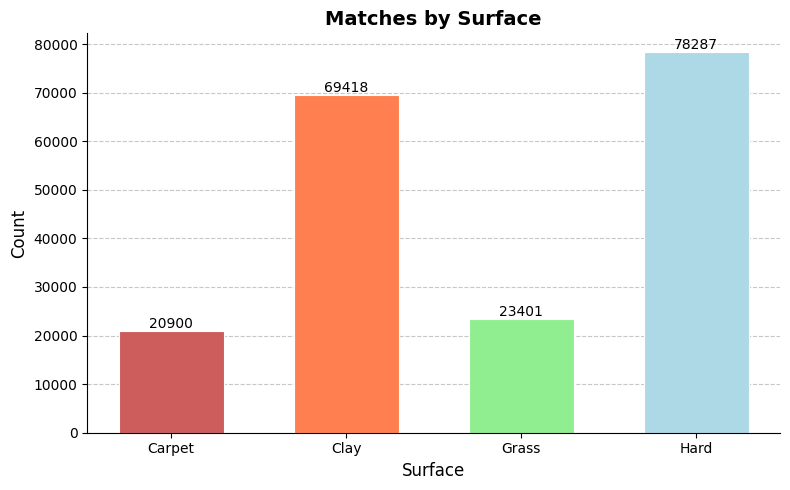

In [50]:
df_surfaces = df_atp_matches.groupby('surface').size().reset_index(name='count')
df_surfaces = df_surfaces[df_surfaces['surface'].isin(['Clay', 'Hard', 'Grass', 'Carpet'])]

fig, ax = plt.subplots(figsize=(8, 5))

colors = {'Clay': 'coral', 'Hard': 'lightblue', 'Grass': 'lightgreen', 'Carpet': 'indianred'}

ax.bar(
    df_surfaces['surface'],
    df_surfaces['count'],
    color=[colors[s] for s in df_surfaces['surface']],
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        int(bar.get_height()),
        ha='center', va='bottom',
        fontsize=10
    )

ax.set_xlabel('Surface', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Matches by Surface', fontsize=14, fontweight='bold')

ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

/var/folders/s5/t7gxskm17flg_z98mm9kxymc0000gn/T/ipykernel_86578/4202996473.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Accent', len(df_tourney_level))


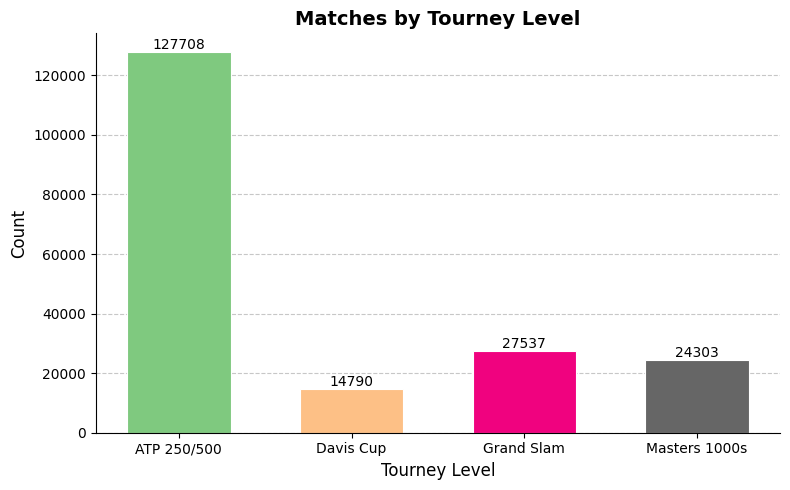

In [51]:
df_tourney_level = df_atp_matches.groupby('tourney_level').size().reset_index(name='count')
df_tourney_level = df_tourney_level[df_tourney_level['tourney_level'].isin(['S','C','A','G','M','D'])]

level_names = {
    'A': 'ATP 250/500',
    'G': 'Grand Slam',
    'M': 'Masters 1000s',
    'D': 'Davis Cup'
}

df_tourney_level['tourney_level'] = df_tourney_level['tourney_level'].map(level_names)

fig, ax = plt.subplots(figsize=(8, 5))

cmap = cm.get_cmap('Accent', len(df_tourney_level))
colors = [cmap(i) for i in range(len(df_tourney_level))]

ax.bar(
    df_tourney_level['tourney_level'],
    df_tourney_level['count'],
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        int(bar.get_height()),
        ha='center', va='bottom',
        fontsize=10
    )

ax.set_xlabel('Tourney Level', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Matches by Tourney Level', fontsize=14, fontweight='bold')

ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Rankings

/var/folders/s5/t7gxskm17flg_z98mm9kxymc0000gn/T/ipykernel_86578/1562862632.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Paired', len(top_players_df))


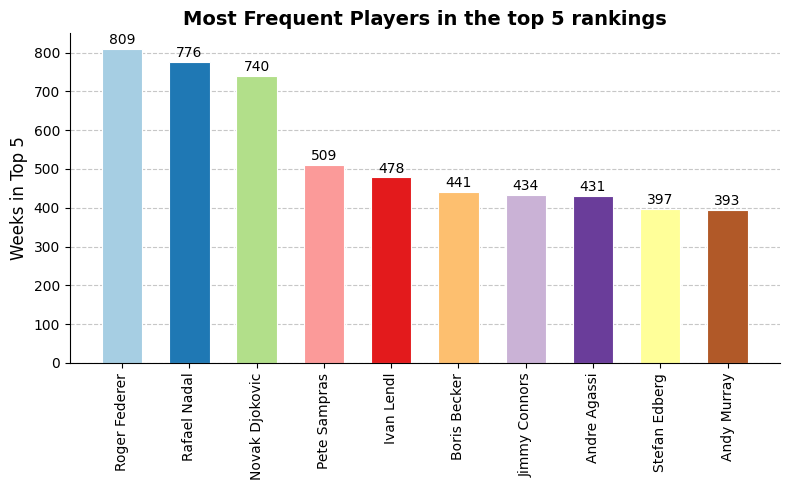

In [52]:
df_rankings_top5 = df_rankings[df_rankings['rank'] <= 5]

top_players_df = (df_rankings_top5['full_name']
               .value_counts()
               .head(10)
               .reset_index(name='count'))


fig, ax = plt.subplots(figsize=(8, 5))

cmap = cm.get_cmap('Paired', len(top_players_df))
colors = [cmap(i) for i in range(len(top_players_df))]

ax.bar(
    top_players_df['full_name'],
    top_players_df['count'],
    color=colors,
    edgecolor='white',
    linewidth=0.8,
    width=0.6
)
for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        int(bar.get_height()),
        ha='center', va='bottom',
        fontsize=10
    )

ax.set_ylabel('Weeks in Top 5', fontsize=12)
ax.set_title('Most Frequent Players in the top 5 rankings', fontsize=14, fontweight='bold')

ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

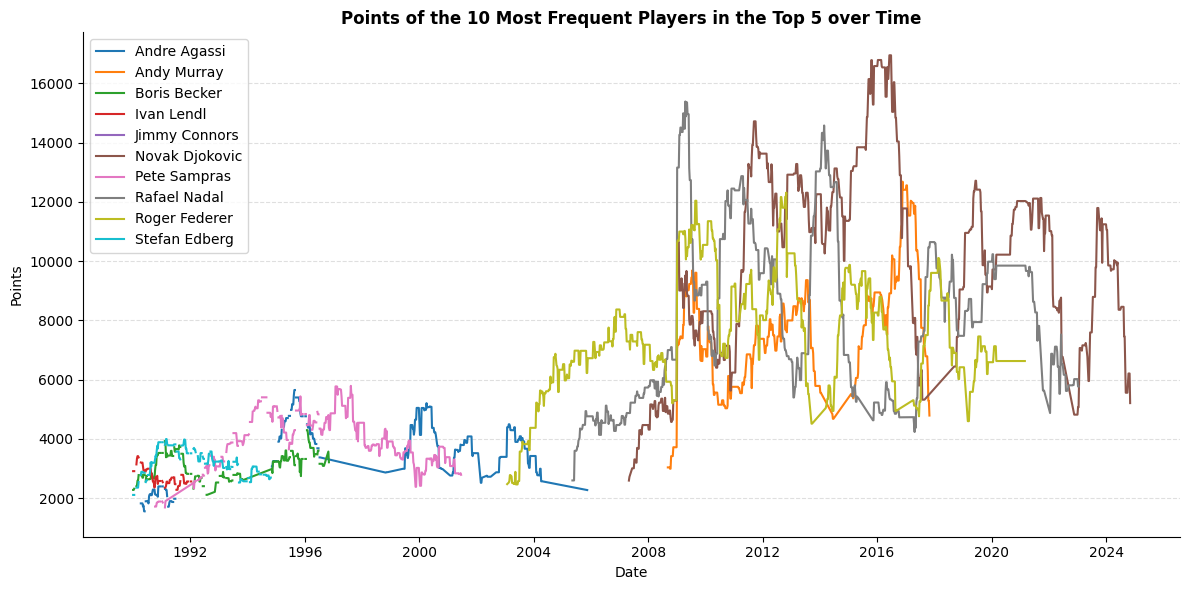

In [ ]:
top_players = top_players_df['full_name']

df_plot = df_rankings_top5[df_rankings_top5['full_name'].isin(top_players)]

fig, ax = plt.subplots(figsize=(12, 6))

cmap = plt.colormaps['tab10'].resampled(len(top_players))

for i, (name, group) in enumerate(df_plot.groupby('full_name')):
    group = group.sort_values('ranking_date')
    ax.plot(group['ranking_date'], group['points'], label=name, color=cmap(i), linewidth=1.5)

ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
ax.set_xlabel('Date')
ax.set_ylabel('Points')
ax.legend()
ax.set_title('Points of the 10 Most Frequent Players in the Top 5 over Time', fontweight='bold')

plt.subplots_adjust(right=0.85)
plt.tight_layout()
plt.show()